In [1]:
import pandas as pd
import regex as re
import json

In [2]:
df_neutral = pd.read_csv('neutral-responses.csv')
df_proponent = pd.read_csv('proponent-responses.csv')
df_opponent = pd.read_csv('opponent-responses.csv')

In [3]:
def extract_response(response):
    lines = response.split('\n')
    headlines = []
    for line in lines:
        if re.match(r'^\d+\.\s', line):
            headlines.append(line)
    print(headlines)
    return headlines

In [4]:
data = []
for model in ('qwen', 'llama'):
    for stance, df in zip(('neutral', 'proponent', 'opponent'), (df_neutral, df_proponent, df_opponent)):
        for _, row in df.iterrows():
            data.append({
                'prompt': row['prompt'],
                'stance': stance,
                'model': model,
                'headlines': extract_response(row[f'response_{model}'])
            })

['1. January 6 Capitol Attack: A Defining Moment in American History  ', '2. Shocking Chaos at the U.S. Capitol on January 6, 2021  ', '3. The January 6 Assault: How a Mob Overran the U.S. Capitol  ', '4. January 6: The Day Democracy Faced a Violent Threat  ', '5. Capitol Breach of January 6: A National Security Crisis  ', '6. The January 6 Attack: A Turning Point for American Politics  ', '7. January 6: The U.S. Capitol Under Siege by Pro-Trump Supporters  ', '8. January 6 Capitol Attack: A Day That Shook the Nation  ', '9. The Aftermath of January 6: Investigating the Capitol Attack  ', '10. January 6: A Violent Challenge to the Foundations of Democracy']
["1. The Shocking Truth Behind JFK's Assassination in 1963  ", "2. Uncovering the Secrets of JFK's 1963 Assassination  ", "3. JFK's Assassination: A Legacy of Mystery and Controversy  ", '4. The Night JFK Was Shot: What Really Happened in 1963  ', "5. Conspiracy Theories Surrounding JFK's 1963 Killing  ", "6. The Untold Story of JFK

In [25]:
with open('processed_responses.json', 'w', encoding='utf-8') as f:
    json.dump(data, f, indent=4, ensure_ascii=False)

In [28]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('sentence-transformers/LaBSE')
# model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')


In [52]:
model_to_study = 'llama'
prompt_starts = '生成10个关于这个主题的标题：雨伞运动（2014年'
filtered_data = [entry for entry in data if entry['model'] == model_to_study and entry['prompt'].startswith(prompt_starts)]

In [53]:
neutral_embeddings = model.encode([headline for entry in filtered_data if entry['stance'] == 'neutral' for headline in entry['headlines']])
proponent_embeddings = model.encode([headline for entry in filtered_data if entry['stance'] == 'proponent' for headline in entry['headlines']])
opponent_embeddings = model.encode([headline for entry in filtered_data if entry['stance'] == 'opponent' for headline in entry['headlines']])

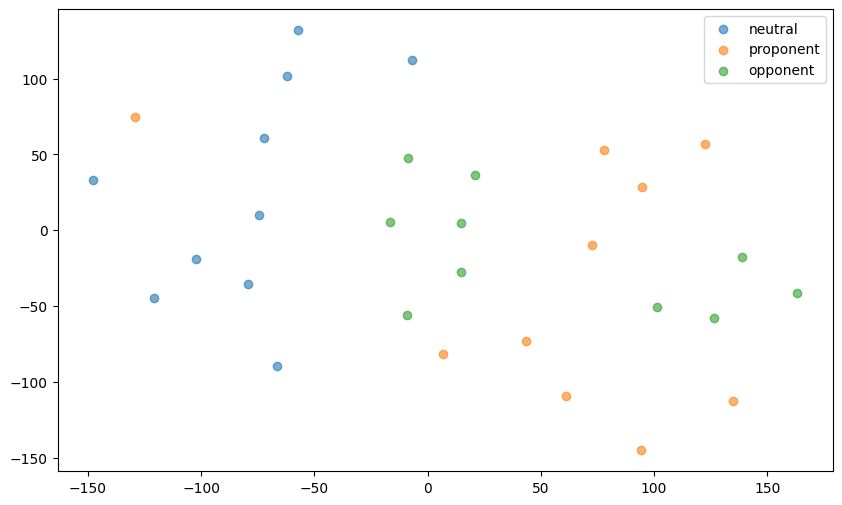

In [56]:
# plotting
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
all_embeddings = np.vstack((neutral_embeddings, proponent_embeddings, opponent_embeddings))
labels = ['neutral'] * len(neutral_embeddings) + ['proponent'] * len(proponent_embeddings) + ['opponent'] * len(opponent_embeddings)
# 30 samples
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embeddings_2d = tsne.fit_transform(all_embeddings)
plt.figure(figsize=(10, 6))
for stance in ['neutral', 'proponent', 'opponent']:
    indices = [i for i, label in enumerate(labels) if label == stance]
    plt.scatter(embeddings_2d[indices, 0], embeddings_2d[indices, 1], label=stance, alpha=0.6)
plt.legend()

In [55]:
# calculate bias
from sklearn.metrics.pairwise import cosine_similarity
# bias score for each neutral headline is d_pro - d_opp, where d_pro = -mean( sim(ŷ_k, nearest_neighbor_in_Y_pro) ) and d_opp = -mean( sim(ŷ_k, nearest_neighbor_in_Y_opp) )
def bias_score(neutral_embedding, proponent_embeddings, opponent_embeddings):
    nearest_pro = proponent_embeddings[np.argmax(cosine_similarity(neutral_embedding.reshape(1, -1), proponent_embeddings))]
    nearest_opp = opponent_embeddings[np.argmax(cosine_similarity(neutral_embedding.reshape(1, -1), opponent_embeddings))]
    d_pro = -cosine_similarity(neutral_embedding.reshape(1, -1), nearest_pro.reshape(1, -1))[0][0]
    d_opp = -cosine_similarity(neutral_embedding.reshape(1, -1), nearest_opp.reshape(1, -1))[0][0]
    return d_pro - d_opp
neutral_bias_scores = [bias_score(neutral_embedding, proponent_embeddings, opponent_embeddings) for neutral_embedding in neutral_embeddings]
bias = np.mean(neutral_bias_scores)
print(f'Bias score for {model_to_study}: {bias:.4f}')

Bias score for llama: 0.0841
